Loaded Q table from artifacts\q_agent.npz
Saved Q table to artifacts\q_agent.npz
Saved last episode traces to artifacts\q_last_episode.npz


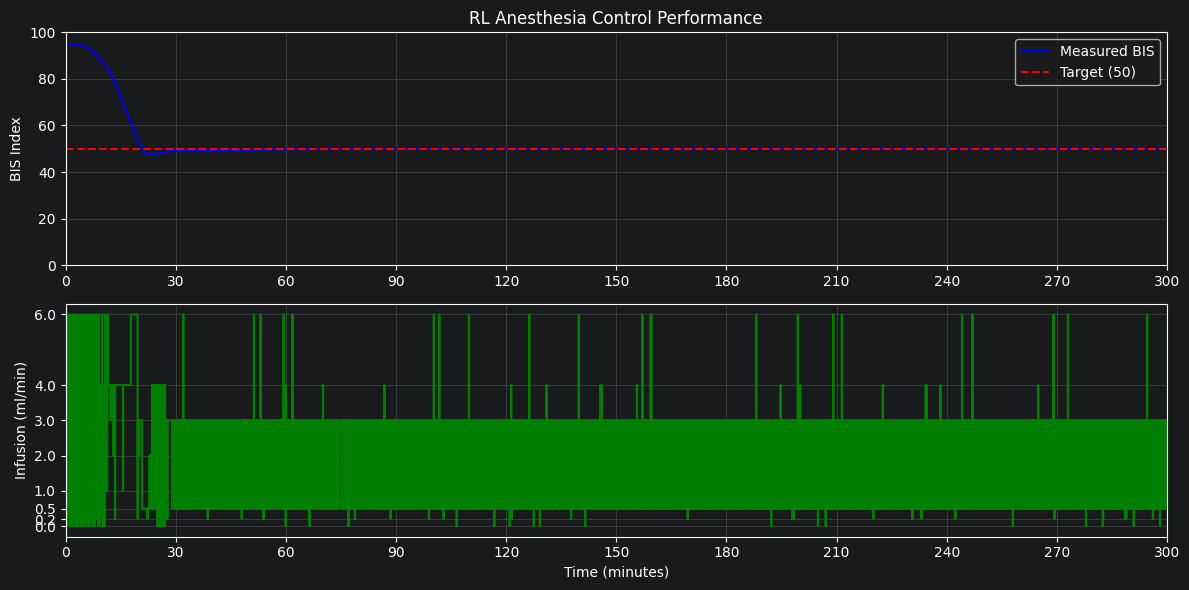

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- MODIFIABLE PARAMETERS ---
TARGET_BIS = 50.0
EPISODES = 5000
STEPS_PER_EP = 3600  # 10 minutes (5s steps)
ALPHA = 0.2         # Learning rate
GAMMA = 0.69        # Discount factor
EPSILON = 0.05      # Exploration

# --- SCHNIDER PK/PD CONSTANTS ---
V1, ke0 = 4.27, 0.17
k10, k12, k21, k13, k31 = 0.38, 0.30, 0.20, 0.19, 0.0035
BIS_0, BIS_MAX, EC50, HILL = 95.0, 75.0, 3.5, 2.5
ACTIONS = [0.0, 0.2, 0.5, 1.0, 2.0, 3.0, 4.0, 6.0]

# --- ARTIFACT PERSISTENCE ---
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
Q_PATH = ARTIFACTS_DIR / "q_agent.npz"
TRACE_PATH = ARTIFACTS_DIR / "q_last_episode.npz"

def get_state(error, delta):
    """Mappe inputs to discrete state using fuzzy logic scales [10, 11]"""
    # Scale: Error/20, Delta/10. Convert 3-func membership to index
    f1 = np.clip((error + 20) / 40, 0, 0.99)
    f2 = np.clip((delta + 10) / 20, 0, 0.99)
    return int(f1 * 10) * 10 + int(f2 * 10)

# --- LOAD OR INITIALIZE Q TABLE ---
if Q_PATH.exists():
    q_data = np.load(Q_PATH)
    Q = q_data["Q"]
    print(f"Loaded Q table from {Q_PATH}")
else:
    Q = np.zeros((100, len(ACTIONS)))
    print("Initialized new Q table")
bis_history = []
action_history = []

for ep in range(EPISODES):
    c1, c2, c3, ce = 0.0, 0.0, 0.0, 0.0
    err, prev_err = (BIS_0 - TARGET_BIS), (BIS_0 - TARGET_BIS)

    for t in range(STEPS_PER_EP):
        s = get_state(err, err - prev_err)

        # Epsilon-greedy selection
        a_idx = np.random.randint(len(ACTIONS)) if np.random.rand() < EPSILON else np.argmax(Q[s])
        u = ACTIONS[a_idx]

        # Update PK/PD (Euler 5s step) [12, 13]
        dt = 5/60
        c1 += (u - (k10 + k12 + k13)*c1 + k21*c2 + k31*c3) / V1 * dt
        c2 += (k12*c1 - k21*c2) * dt
        c3 += (k13*c1 - k31*c3) * dt
        ce += ke0 * (c1 - ce) * dt

        bis = BIS_0 - BIS_MAX * (ce**HILL / (ce**HILL + EC50**HILL))
        next_err = bis - TARGET_BIS
        reward = -abs(next_err) # [14]

        # Q-Learning update [15]
        s_next = get_state(next_err, next_err - err)
        Q[s, a_idx] += ALPHA * (reward + GAMMA * np.max(Q[s_next]) - Q[s, a_idx])

        if ep == EPISODES - 1: # Log only the last episode for plotting
            bis_history.append(bis)
            action_history.append(u)

        prev_err, err = err, next_err

# --- SAVE TRAINED Q TABLE AND TRACES ---
np.savez_compressed(
    Q_PATH,
    Q=Q,
    actions=np.array(ACTIONS, dtype=float),
    target_bis=np.array([TARGET_BIS], dtype=float),
    alpha=np.array([ALPHA], dtype=float),
    gamma=np.array([GAMMA], dtype=float),
    epsilon=np.array([EPSILON], dtype=float),
)
np.savez_compressed(
    TRACE_PATH,
    bis_history=np.array(bis_history, dtype=float),
    action_history=np.array(action_history, dtype=float),
)
print(f"Saved Q table to {Q_PATH}")
print(f"Saved last episode traces to {TRACE_PATH}")

# --- PLOTTING (NO MANIM) [1, 2] ---
plt.figure(figsize=(12, 6))

# Convert step indices to time (minutes)
if len(bis_history) > 0:
    t_sec = np.arange(len(bis_history)) * 5            # seconds
    t_min = t_sec / 60.0                               # minutes
else:
    t_min = np.array([])

max_min = (STEPS_PER_EP * 5) / 60.0
# choose a reasonable tick spacing: aim for ~8-12 ticks across the x axis
approx_ticks = 10
tick_step = max(1, int(np.ceil(max_min / approx_ticks)))
xticks = np.arange(0, max_min + 1e-8, tick_step)

# Top: BIS levels (plot vs minutes)
plt.subplot(2, 1, 1)
plt.plot(t_min, bis_history, label="Measured BIS", color="blue")
plt.axhline(TARGET_BIS, color="red", linestyle="--", label=f"Target ({TARGET_BIS:.0f})")
plt.ylabel("BIS Index")
plt.title("RL Anesthesia Control Performance")
plt.ylim(0, 100)
plt.xlim(0, max_min)
plt.xticks(xticks)
plt.legend()
plt.grid(True, alpha=0.3)

# Bottom: Infusion rates (plot vs minutes)
plt.subplot(2, 1, 2)
plt.step(t_min, action_history, color="green", where="post")
plt.ylabel("Infusion (ml/min)")
plt.xlabel("Time (minutes)")
plt.xlim(0, max_min)
# Show ticks on y for available discrete action values
plt.yticks(ACTIONS)
plt.xticks(xticks)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# EVALUATION ON POPULATION DATASET

In [5]:
import pandas as pd
import random
from scipy.stats import linregress

# 1. Data Loading and Preprocessing
def load_data(path: str):
    return pd.read_csv(path)

def preprocess_data(df: pd.DataFrame):
    df = df.copy()
    def parse_age(x):
        try:
            parts = str(x).strip().split(" ")
            if len(parts) < 2: return 50
            low = int(parts[1])
            if len(parts) > 3:
                if parts[3] == 'older':
                    high = 100
                else:
                    high = int(parts[3])
                return int(random.randrange(low, high))
            return int(low)
        except Exception:
            return 50 # Default fallback

    if "AgeCategory" in df.columns:
        df.loc[:,"AgeCategory"] = df["AgeCategory"].apply(parse_age)
    return df

def schnider_model(age: int, weight: float, height: float, sex: str) -> dict:
    sex = str(sex).lower()
    if sex == "male":
        lbm = 1.10 * weight - 128 * (weight ** 2) / (height ** 2)
    else:
        lbm = 1.07 * weight - 148 * (weight ** 2) / (height ** 2)

    V1 = 4.27
    V2 = 18.9 - 0.391 * (age - 53)
    V3 = 238.0

    k10 = 0.443 + 0.0107 * (weight - 77) - 0.0159 * (lbm - 59) + 0.0062 * (height - 177)
    k12 = 0.302 - 0.0056 * (age - 53)
    k13 = 0.196
    k21 = (1.29 - 0.024 * (age - 53)) / V2
    k31 = 0.0035
    ke0 = 0.456

    A = np.array([
        [-(k10 + k12 + k13),  k21,  k31,   0   ],
        [        k12,         -k21,   0,    0   ],
        [        k13,          0,   -k31,   0   ],
        [        ke0,          0,    0,   -ke0  ]
    ])
    B = np.array([[1 / V1], [0], [0], [0]])
    # Return A and B as lists to avoid pandas creating issues with numpy arrays in cells during concat sometimes
    # But for now, returning as numpy arrays in dict is standard, we must ensure retrieval is correct.
    return {"A": A, "B": B}

def generate_schnider_dataset(df: pd.DataFrame):
    # Fusing parameters to each row safely
    params_list = []
    for _, row in df.iterrows():
        params = schnider_model(
            age=row["AgeCategory"],
            weight=row["WeightInKilograms"],
            height=row["HeightInMeters"],
            sex=row["Sex"]
        )
        params_list.append(params)

    # Create DataFrame from list of dicts
    params_df = pd.DataFrame(params_list)
    # Concatenate with original dataframe
    return pd.concat([df.reset_index(drop=True), params_df], axis=1)

# 2. Evaluator for Q-Learning Agent (100 states, 2 features)
class QEvaluator:
    def __init__(self, q_table, actions):
        self.Q = q_table
        self.actions = actions
        self.target = 50.0
        self.bis0 = 95.0
        self.bis_max = 75.0
        self.ec50 = 3.5
        self.hill = 2.5

    def _get_state_idx(self, error, delta):
        # Match feature extraction from Q-learning part
        # Convert to float and check for NaN FIRST
        error = float(error) if np.isfinite(error) else 0.0
        delta = float(delta) if np.isfinite(delta) else 0.0

        # Clamp to valid range
        error = np.clip(error, -50.0, 50.0)
        delta = np.clip(delta, -30.0, 30.0)

        f1 = np.clip((error + 20) / 40, 0, 0.99)
        f2 = np.clip((delta + 10) / 20, 0, 0.99)

        # Ensure f1 and f2 are finite before converting to int
        f1 = f1 if np.isfinite(f1) else 0.5
        f2 = f2 if np.isfinite(f2) else 0.5

        # Convert to integers with safety checks
        f1_int = int(np.clip(f1 * 10, 0, 9))
        f2_int = int(np.clip(f2 * 10, 0, 9))

        idx = f1_int * 10 + f2_int

        # Final bounds check
        idx = min(idx, len(self.Q) - 1)
        idx = max(idx, 0)

        return idx

    def simulate(self, patient_row, duration_min=120):
        dt = 5/60
        steps = int(duration_min / dt)

        # Extract A and B matrices safely (convert from object arrays if needed)
        A = np.asarray(patient_row['A'], dtype=float)
        B = np.asarray(patient_row['B'], dtype=float)

        # Initialize state vector: start at awake state (BIS=95, ce=0)
        x = np.zeros((4, 1), dtype=float)

        pe_log = []
        bis_log = []
        prev_error = 0.0

        # Safety limits to prevent model instability
        MAX_CONCENTRATION = 10.0  # µg/ml - reasonable max for propofol

        for t in range(steps):
            # BIS Output from effect-site concentration
            ce = float(x[3, 0])

            # Strictly clamp ce to prevent NaN and model instability
            ce = np.clip(ce, 0.0, MAX_CONCENTRATION)

            # Safeguard: if any state component is NaN or inf, reset to safe value
            if not np.isfinite(ce):
                ce = 0.0
                x = np.zeros((4, 1), dtype=float)

            # Hill equation: BIS = BIS_0 - BIS_MAX * (Ce^H / (Ce^H + EC50^H))
            ce_h = np.power(ce, self.hill, dtype=np.float64)  # Use np.power for safety
            ce_h = np.clip(ce_h, 0, 1e6)  # Prevent overflow

            ec50_h = np.power(self.ec50, self.hill, dtype=np.float64)
            ec50_h = np.clip(ec50_h, 0, 1e6)

            denom = ce_h + ec50_h
            if denom > 0 and np.isfinite(denom):
                bis_ideal = self.bis0 - self.bis_max * (ce_h / denom)
            else:
                bis_ideal = self.bis0

            # Ensure bis_ideal is finite
            if not np.isfinite(bis_ideal):
                bis_ideal = self.bis0

            # Clamp BIS to valid range and add measurement noise
            bis_ideal = np.clip(float(bis_ideal), 0, 100)
            measured_bis = bis_ideal + np.random.normal(0, 3)
            measured_bis = np.clip(measured_bis, 0, 100)

            # RL Perception
            error = float(measured_bis - self.target)
            delta = float(error - prev_error)

            # Safeguard: ensure error and delta are finite BEFORE any use
            error = 0.0 if not np.isfinite(error) else error
            delta = 0.0 if not np.isfinite(delta) else delta

            # Clamp to reasonable ranges
            error = np.clip(error, -50.0, 50.0)
            delta = np.clip(delta, -30.0, 30.0)

            # Double-check they are still finite
            assert np.isfinite(error) and np.isfinite(delta), f"NaN detected: error={error}, delta={delta}"

            s_idx = self._get_state_idx(error, delta)

            # Greedy Action
            a_idx = int(np.argmax(self.Q[s_idx]))
            u = float(self.actions[a_idx])

            # PK update: dx/dt = Ax + Bu
            x_dot = A @ x + B * u
            x = x + x_dot * dt

            # Clamp all state variables to prevent explosion
            x = np.clip(x, -MAX_CONCENTRATION, MAX_CONCENTRATION)

            pe_log.append(100.0 * error / self.target if self.target != 0 else 0.0)
            bis_log.append(float(measured_bis))
            prev_error = error

        return bis_log, pe_log

    def evaluate(self, df):
        summary = []
        for idx, row in df.iterrows():
            try:
                bis, pe = self.simulate(row)
                mdpe = np.median(pe)
                mdape = np.median(np.abs(pe))
                wobble = np.median(np.abs(pe - mdpe))
                controlled = (np.abs(np.array(bis) - self.target) <= 5).mean() * 100
                summary.append({
                    'PatientID': row['PatientID'],
                    'MDPE': mdpe, 'MDAPE': mdape,
                    'Wobble': wobble, 'Controlled (%)': controlled
                })
            except Exception as e:
                print(f"Warning: Failed to evaluate patient {row['PatientID']}: {e}")
                continue
        return pd.DataFrame(summary)

# 3. Execution
from utils.eval_runner import run_quick_q_evaluation

results_df = run_quick_q_evaluation(
    q_path=Q_PATH,
    evaluator_cls=QEvaluator,
    load_data_fn=load_data,
    preprocess_data_fn=preprocess_data,
    generate_dataset_fn=generate_schnider_dataset,
    sample_size=50,
)


Loading Population Data...
Sampling 50 patients from 237630 total.
Loading DP Agent...
Evaluating on Population...

--- Evaluation Results Summary ---
            MDPE      MDAPE     Wobble  Controlled (%)
count  50.000000  50.000000  50.000000            50.0
mean   89.921863  89.921863   4.060514             0.0
std     0.136006   0.136006   0.124699             0.0
min    89.632326  89.632326   3.823317             0.0
25%    89.848608  89.848608   3.976324             0.0
50%    89.907349  89.907349   4.049201             0.0
75%    90.017412  90.017412   4.114975             0.0
max    90.282691  90.282691   4.350031             0.0

Best Patient: {'PatientID': 17305.0, 'MDPE': 89.63232605719453, 'MDAPE': 89.63232605719453, 'Wobble': 4.0116032324359665, 'Controlled (%)': 0.0}


# LOAD AND EVALUATE SAVED Q-LEARNING AGENT

In [6]:
from utils.eval_runner import run_saved_q_evaluation

results_df = run_saved_q_evaluation(
    q_path=Q_PATH,
    evaluator_cls=QEvaluator,
    load_data_fn=load_data,
    preprocess_data_fn=preprocess_data,
    generate_dataset_fn=generate_schnider_dataset,
    sample_size=100,
)


LOADING SAVED Q-LEARNING AGENT

Loading agent from: artifacts\q_agent.npz
  - Loaded Q table: shape (100, 8)
  - Actions available: [0.  0.2 0.5 1.  2.  3.  4.  6. ]
  - Target BIS: [50.]
  - Learning rate (alpha): [0.2]
  - Discount factor (gamma): [0.69]
  - Exploration rate (epsilon): [0.05]

EVALUATING ON POPULATION SAMPLE

Sampling 100 patients from 237630 total...
Generating Schnider parameters for 100 patients...

Running evaluation simulation (120 min per patient)...

EVALUATION RESULTS

Evaluated 100 patients successfully

             MDPE       MDAPE      Wobble  Controlled (%)
count  100.000000  100.000000  100.000000           100.0
mean    89.986694   89.986694    4.027254             0.0
std      0.189644    0.189644    0.133912             0.0
min     89.504399   89.504399    3.729610             0.0
25%     89.856830   89.856830    3.927837             0.0
50%     90.014157   90.014157    4.031115             0.0
75%     90.120042   90.120042    4.113155             0.